In [2]:
import os
import numpy as np
import glob
import xarray as xr
import museval
from museval.utils import get_response, find_response, aia_synthesis, wavelength_in_cube
from muse.synthesis.synthesis import transform_resp_units
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import re
from pathlib import Path
from astropy.time import Time

In [3]:
aia_data_path = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/'
str_prefix = 'QS_AIA_'
aia_data_npz = glob.glob(aia_data_path+str_prefix+'*.npz')
(sorted(aia_data_npz))
for idx, file in enumerate(sorted(aia_data_npz)):
    # print(idx)
    s = file
    stem = Path(s).stem
    m = re.search(r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}", stem)
    dt_str = m.group(0) if m else None

    print(dt_str)
 

2014-04-28T13:22:00
2016-03-20T23:45:00
2016-03-22T00:18:40
2019-08-17T04:33:00
2019-12-01T16:24:00


## Computing the synthetic and observed line ratios for the QS VDEM

In [4]:
os.environ['VDEM_path'] = '/Users/souvikb/MUSE_outputs/vdems/'
vdem_file = os.path.join(os.environ['VDEM_path'], 'muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr')
qs_vdem = xr.open_zarr(vdem_file)
os.environ['RESPONSE'] = '/Users/souvikb/MUSE_outputs/response/new_response/'
work_dir = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/'
# date_sensitive = True
units = 'DN'
channels = [131,171,193,211] # for the Synthetic AIA channels
ratio_over_time = [] #empty to store the ratio
synth_ratio_over_time =[]

for idx, file in enumerate(sorted(aia_data_npz)):
    s = file
    stem = Path(s).stem # gives the filename without directory path and without the final extension
    m = re.search(r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}", stem) # scans stem for a datetime pattern like YYYY-MM-DDTHH:MM:SS
    dt_str = m.group(0) if m else None

    ## Begin the Response function and AIA synthesis section 
    date = Time(dt_str,format='isot',scale='utc') # astropy time object
    print(f' Date Sensitive AIA {units} Response from {date.strftime("%b %y")}')
    aia_resp = get_response(qs_vdem, date = date, save_response = True) # creating AIA response functions on the fly
    muse_AIA_QS = aia_synthesis(aia_resp, work_dir, vdem_file, swap_dims = False) # Synthesizing AIA QS data from VDEM
    
    with np.load(file, allow_pickle=True) as z:
        all_aia_data = {k:z[k] for k in z.files}
    print(f"Processing .npz file: {file}")

    list_ratio = [] #empty to store the ratio
    synth_list_ratio = []
    for k, v in all_aia_data.items():
        # print(k)
        if k == 'a171':
            N_r = v.item().data#/v.item().exposure_time.value # Nr is aia 171
            synth_Nr = muse_AIA_QS.flux.sel(channel=171).squeeze().to_numpy()
            continue
        else:
            # print(k)
            D_r = v.item().data#/v.item().exposure_time.value # Dr is the rest, i.e. 131, 193, 211
            synth_Dr = muse_AIA_QS.flux.sel(channel=int(k[1:])).squeeze().to_numpy()

        synth_list_ratio.append({
            "synth_ratio": synth_Nr/(synth_Dr +1e-2),
            "synth_ratio_name": f"171/{k[1:]}",
        }

        )
        if N_r.shape == D_r.shape:
            # print(f'shape matched:{N_r.shape}')
            ratio = N_r/(D_r + 1e-2)
            # list_ratio.append(ratio)
        else:
            # print('shape mismatched')
            H = min(N_r.shape[0], D_r.shape[0])
            W = min(N_r.shape[1], D_r.shape[1])
            ratio = N_r[:H,:W]/(D_r[:H,:W] + 1e-2)
            # list_ratio.append(ratio)
        list_ratio.append({
            "ratio": ratio,
            "meta": {
                "numerator_key": "a171",
                "denominator_key": k,
                "ratio_name": f"171/{k[1:]}",

            },
        })
    ratio_over_time.append({
        "ratios": list_ratio,
        "date":dt_str,
    })
    synth_ratio_over_time.append({
        "synth_ratios":synth_list_ratio,
        "date": dt_str,
    })

 Date Sensitive AIA DN Response from Apr 14
2026-04-01 16:46:48.465 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 0 months from obs_date 
2026-04-01 16:46:48.466 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Apr14.zarr already exists! Reading...
2026-04-01 16:46:48.561 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-04-01 16:46:48.561 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/
2026-04-01 16:46:48.561 | INFO     | museval.utils:aia_synthesis:403 - *** Loading /Users/souvikb/MUSE_outputs/vdems/muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr into vdem
Processing .npz file: /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_AIA_2014-04-28T13:22:00.npz
 Date Sensitive AIA DN Response from Mar 16
2026-04-01 16:46:48.881 | INFO     | museval.utils:find_respons

In [5]:
ratio_over_time

[{'ratios': [{'ratio': array([[10.75023387, 21.28528299, 34.05099944, ..., 32.20685089,
            25.06365421, 32.75658676],
           [39.15884287, 22.2099812 , 29.10501312, ..., 61.38997142,
            26.11543691, 23.97548527],
           [28.1292812 , 13.12336769, 22.53149115, ..., 44.61803208,
            40.93970799, 24.004234  ],
           ...,
           [13.75147135, 11.48274845, 15.46991102, ..., 22.31120489,
            56.26809355, 24.17425906],
           [22.03507343, 20.29563698,  6.09897374, ..., 31.40671278,
            23.00514271, 37.89991669],
           [33.86216132, 22.15156714, 12.05959915, ..., 26.30638421,
            43.59308313, 88.71291498]]),
    'meta': {'numerator_key': 'a171',
     'denominator_key': 'a131',
     'ratio_name': '171/131'}},
   {'ratio': array([[0.30367243, 0.30219694, 0.43632486, ..., 0.71806598, 0.7133282 ,
            0.65810182],
           [0.26863175, 0.32078489, 0.418392  , ..., 0.99295525, 0.76367609,
            0.64679628],


In [6]:
synth_ratio_over_time

[{'synth_ratios': [{'synth_ratio': array([[49.48148 , 49.209675, 48.684284, ..., 49.07907 , 49.075977,
            49.295338],
           [49.11035 , 49.001522, 49.269463, ..., 48.564835, 48.571484,
            48.83296 ],
           [48.485367, 48.508026, 48.672268, ..., 47.81108 , 48.056114,
            48.303474],
           ...,
           [48.59397 , 48.45024 , 47.932617, ..., 49.5536  , 49.16471 ,
            48.81707 ],
           [48.87001 , 48.76786 , 48.38546 , ..., 49.68279 , 49.51631 ,
            49.199238],
           [49.273445, 48.750496, 48.64863 , ..., 49.800972, 49.63556 ,
            49.396713]], dtype=float32),
    'synth_ratio_name': '171/131'},
   {'synth_ratio': array([[1.2388432, 1.24098  , 1.2489638, ..., 1.1411186, 1.1602048,
            1.1952494],
           [1.1562362, 1.1876836, 1.2324744, ..., 1.1009018, 1.1205473,
            1.1290855],
           [1.10717  , 1.1243638, 1.146199 , ..., 1.0687349, 1.0867156,
            1.0938561],
           ...,
     

# Plotting the line ratios as a function of time

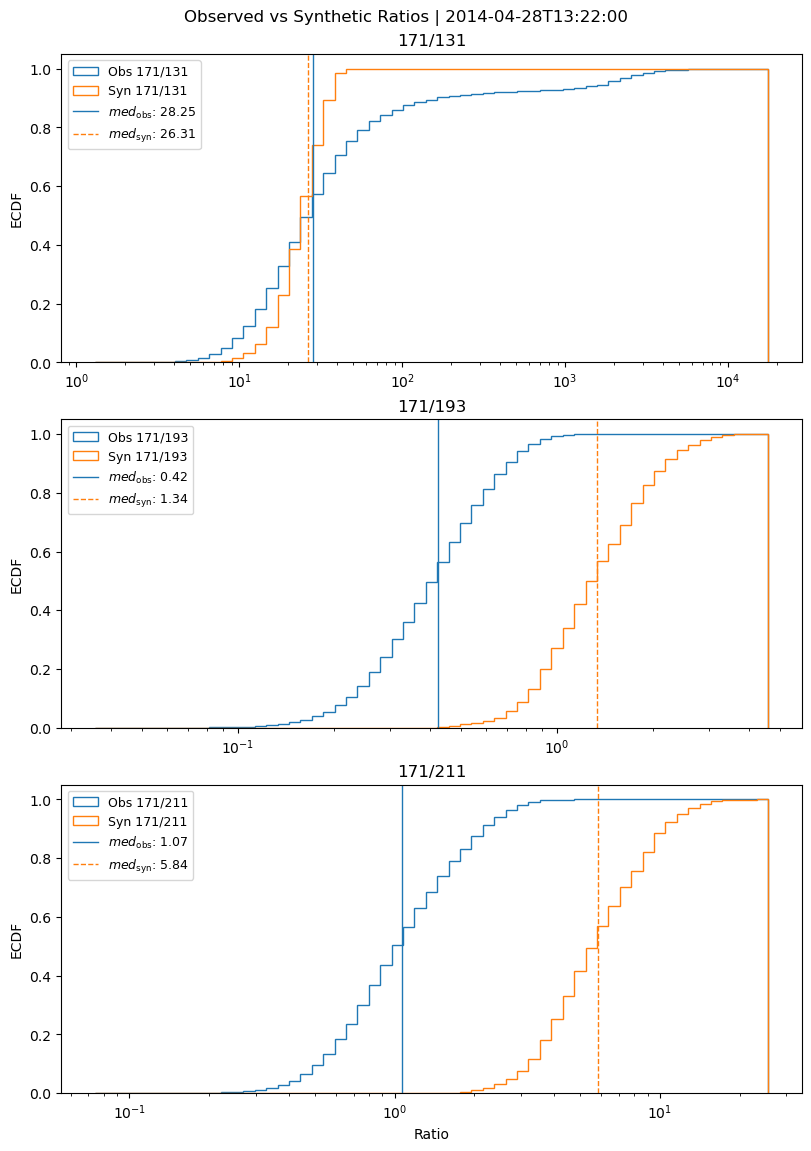

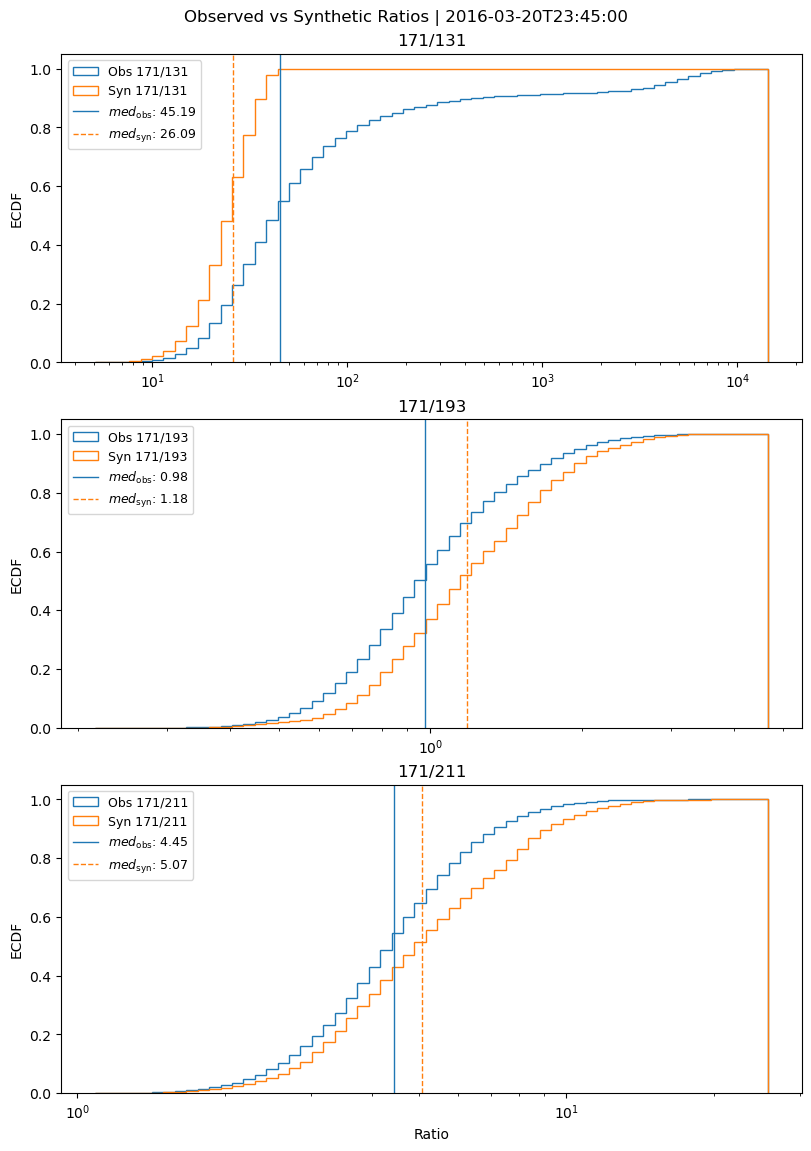

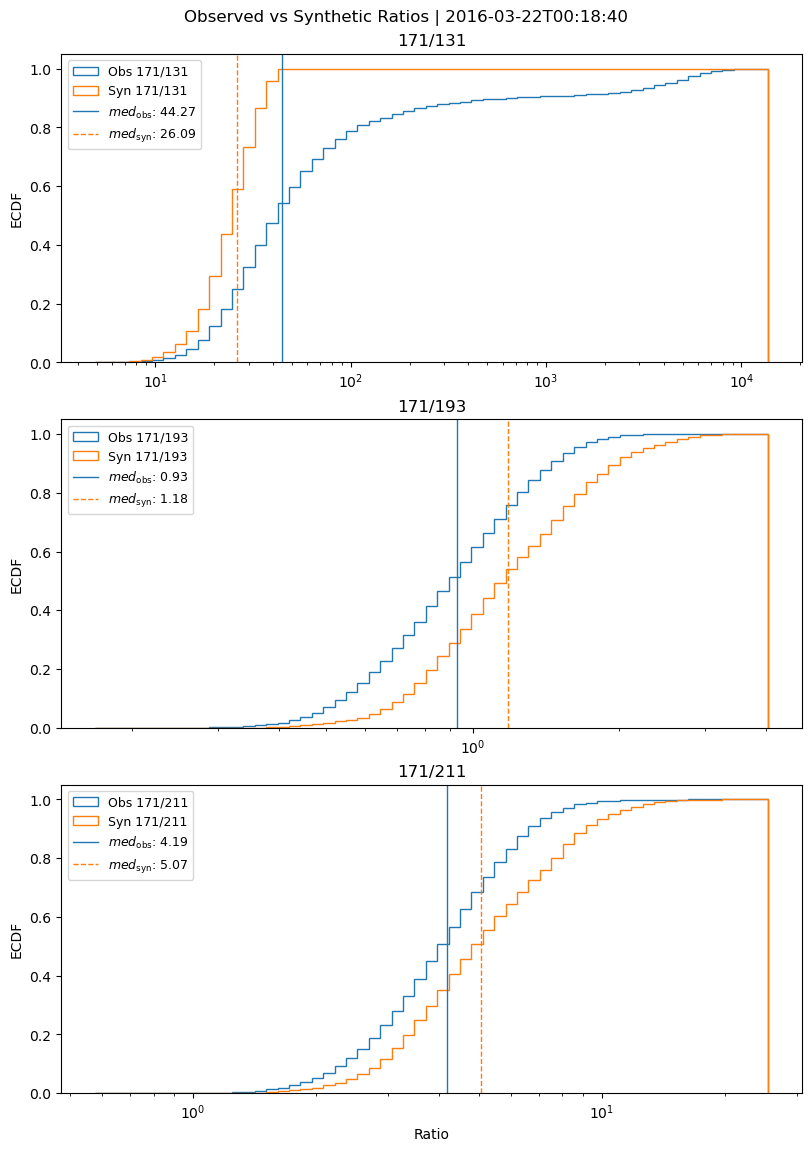

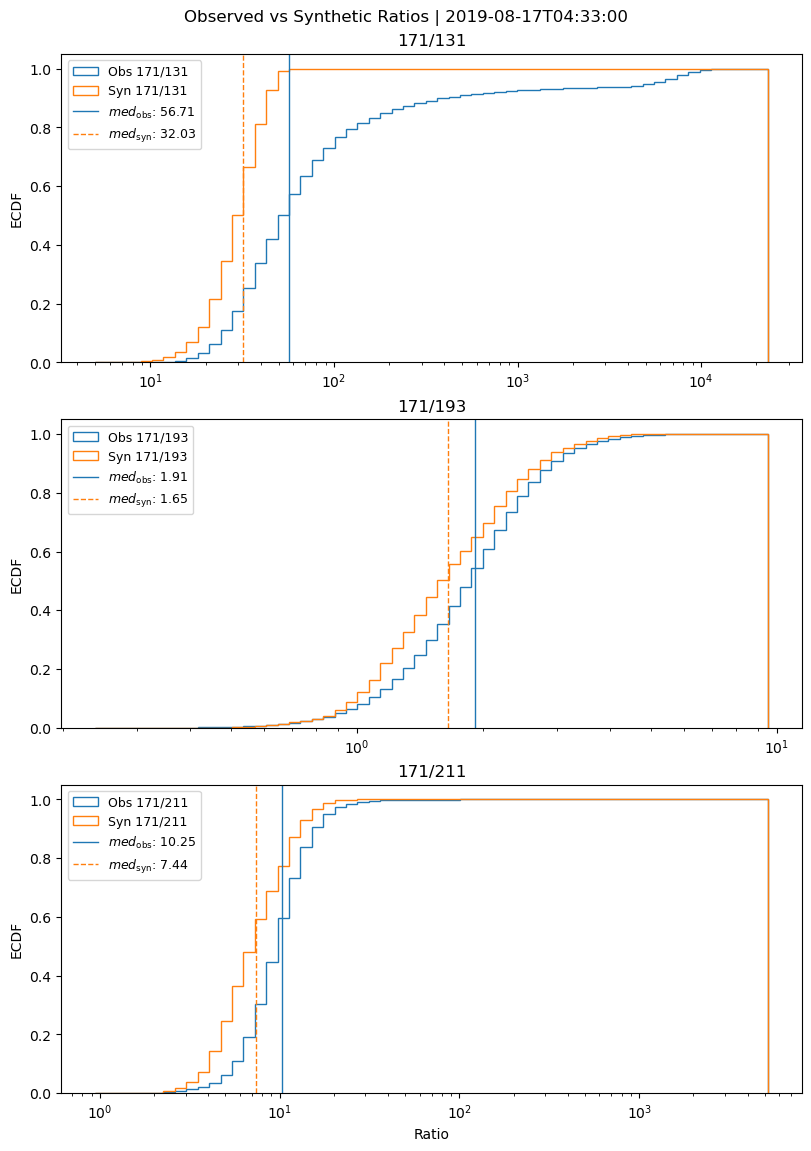

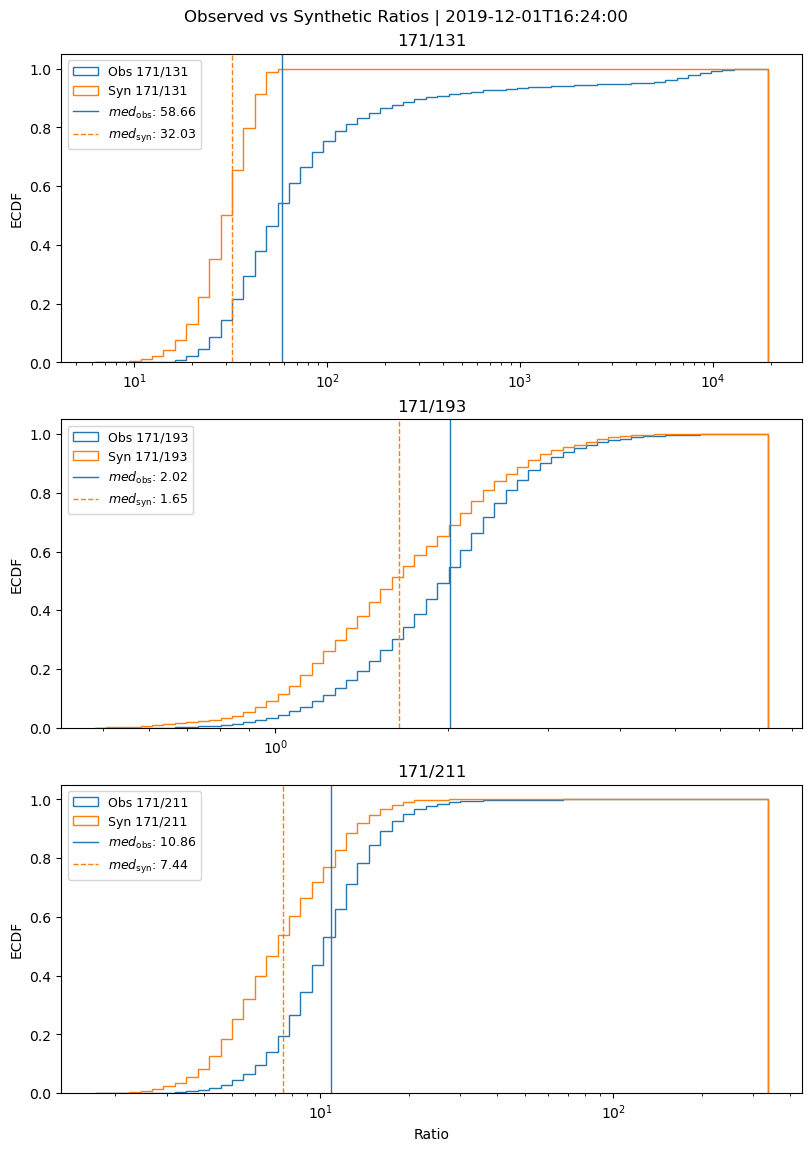

In [32]:
num_bins = 60

# Build date lookup from metadata
obs_by_date = {d["date"]: d for d in ratio_over_time}
syn_by_date = {d["date"]: d for d in synth_ratio_over_time}
common_dates = sorted(set(obs_by_date).intersection(syn_by_date))

for date in common_dates:
    obs_entry = obs_by_date[date]
    syn_entry = syn_by_date[date]

    # Use ratio names from metadata (no hardcoding)
    obs_map = {r["meta"]["ratio_name"]: r["ratio"] for r in obs_entry["ratios"]}
    syn_map = {r["synth_ratio_name"]: r["synth_ratio"] for r in syn_entry["synth_ratios"]}
    ratio_names = sorted(set(obs_map).intersection(syn_map))  # e.g. 171/131, 171/193, 171/211

    fig, axes = plt.subplots(len(ratio_names), 1, figsize=(8, 3.8 * len(ratio_names)), constrained_layout=True)
    if len(ratio_names) == 1:
        axes = [axes]

    fig.suptitle(f"Observed vs Synthetic Ratios | {date}", fontsize=12)

    for ax, rn in zip(axes, ratio_names):
        obs = np.ravel(obs_map[rn]).astype(float)
        syn = np.ravel(syn_map[rn]).astype(float)

        obs = obs[np.isfinite(obs) & (obs > 0)]
        syn = syn[np.isfinite(syn) & (syn > 0)]

        if len(obs) == 0 or len(syn) == 0:
            ax.text(0.5, 0.5, f"No valid data for {rn}", ha="center", va="center")
            ax.set_axis_off()
            continue

        # Shared bins from combined obs+syn (handles different image sizes safely)
        combined = np.concatenate([obs, syn])
        min_val = max(combined.min(), 1e-6)
        max_val = combined.max()
        bins = np.logspace(np.log10(min_val), np.log10(max_val), num_bins)

        ax.hist(obs, bins=bins, cumulative=True, histtype="step",
                weights=np.ones(len(obs))/len(obs), color="tab:blue", lw=2,
                label=f"Obs {rn}")
        ax.hist(syn, bins=bins, cumulative=True, histtype="step",
                weights=np.ones(len(syn))/len(syn), color="tab:orange", lw=2, ls="--",
                label=f"Syn {rn}")

        ax.axvline(np.median(obs), color="tab:blue", lw=1, ls="-",
                   label=f'$med_{{\mathrm{{obs}}}}$: {np.median(obs):.2f}')
        ax.axvline(np.median(syn), color="tab:orange", lw=1, ls="--",
                   label=f'$med_{{\mathrm{{syn}}}}$: {np.median(syn):.2f}')
        # print(date, rn,
        #       "obs q50/q95/q99:", np.quantile(obs, [0.5, 0.95, 0.99]),
        #       "syn q50/q95/q99:", np.quantile(syn, [0.5, 0.95, 0.99]))

        ax.set_xscale("log")
        ax.set_ylabel("ECDF")
        ax.set_title(rn)
        # ax.grid(alpha=0.3)
        ax.legend(fontsize=9)

    axes[-1].set_xlabel("Ratio")
    plt.show()


## Plotting the observed and the synthetic intensities as a function of time

 Date Sensitive AIA DN Response from Apr 14
2026-04-01 16:47:24.623 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 0 months from obs_date 
2026-04-01 16:47:24.624 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Apr14.zarr already exists! Reading...
2026-04-01 16:47:24.647 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-04-01 16:47:24.647 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/
2026-04-01 16:47:24.647 | INFO     | museval.utils:aia_synthesis:403 - *** Loading /Users/souvikb/MUSE_outputs/vdems/muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr into vdem
Processing .npz file: /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_AIA_2014-04-28T13:22:00.npz
 Date Sensitive AIA DN Response from Mar 16
2026-04-01 16:47:25.226 | INFO     | museval.utils:find_respons

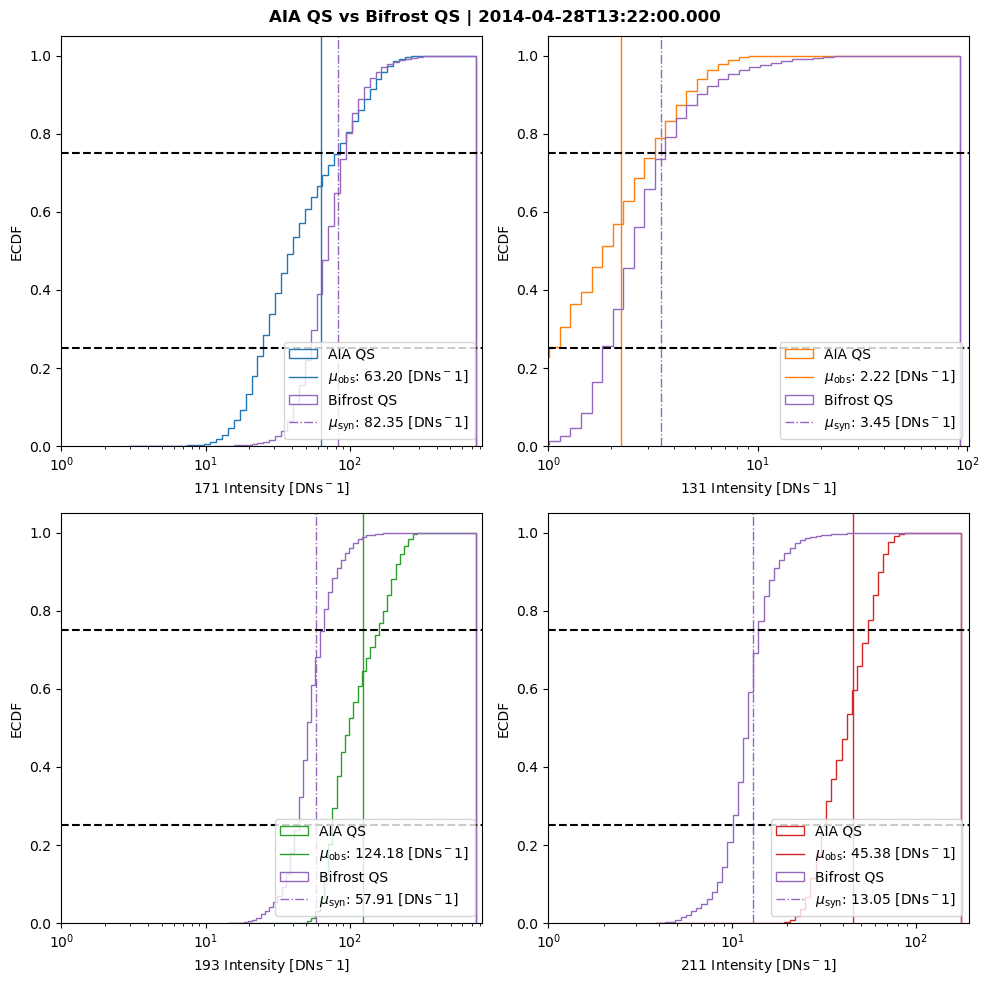

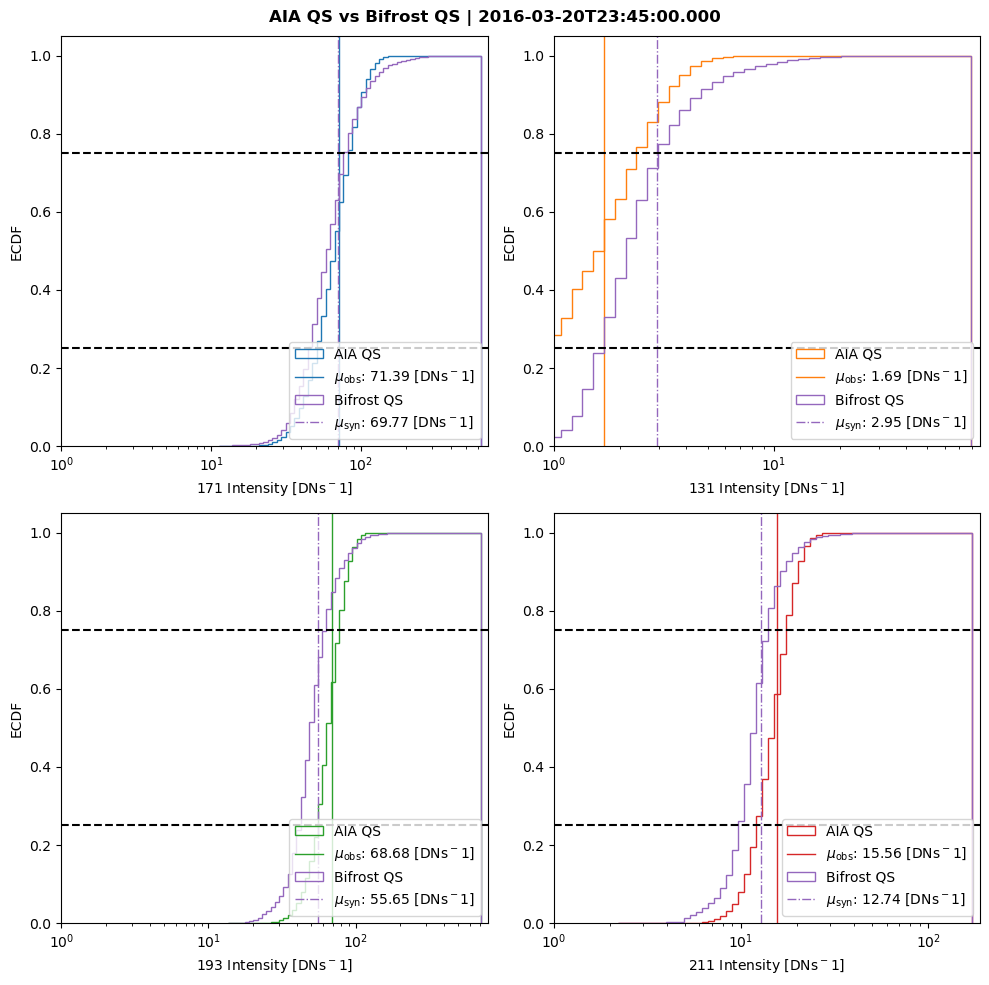

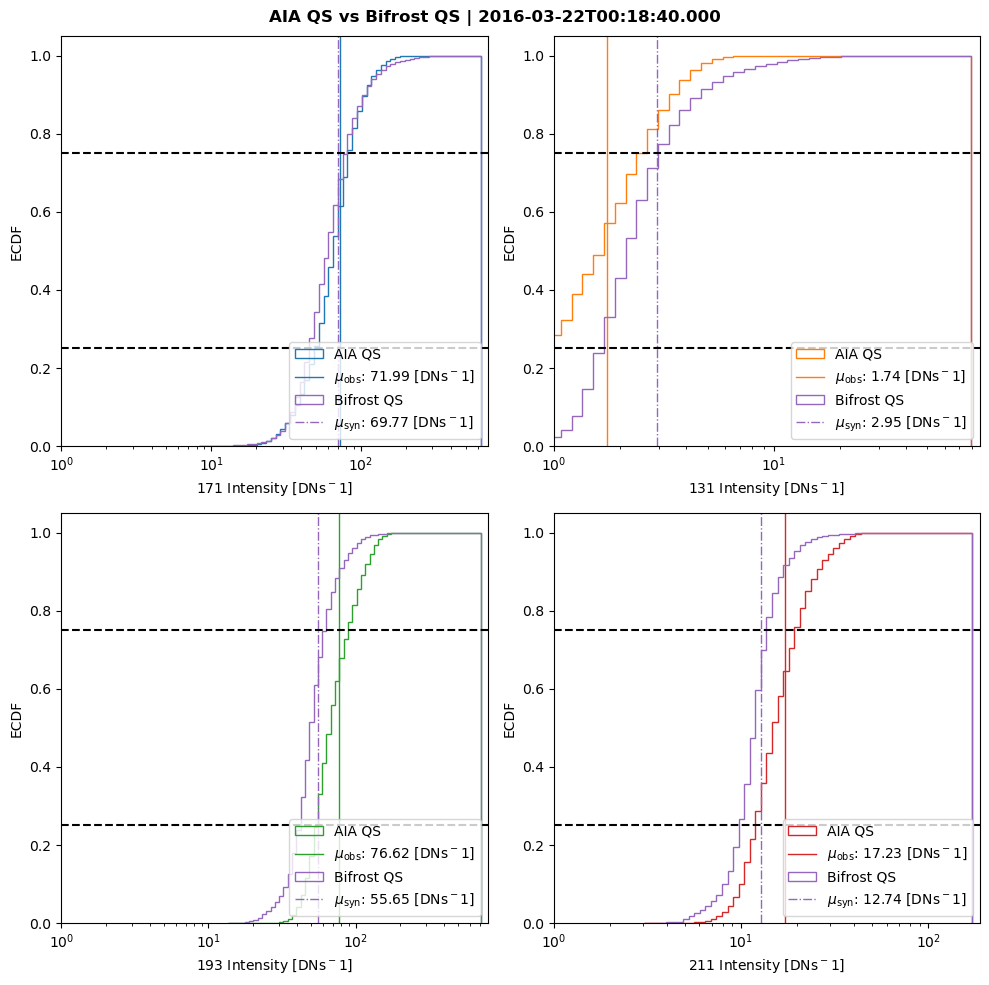

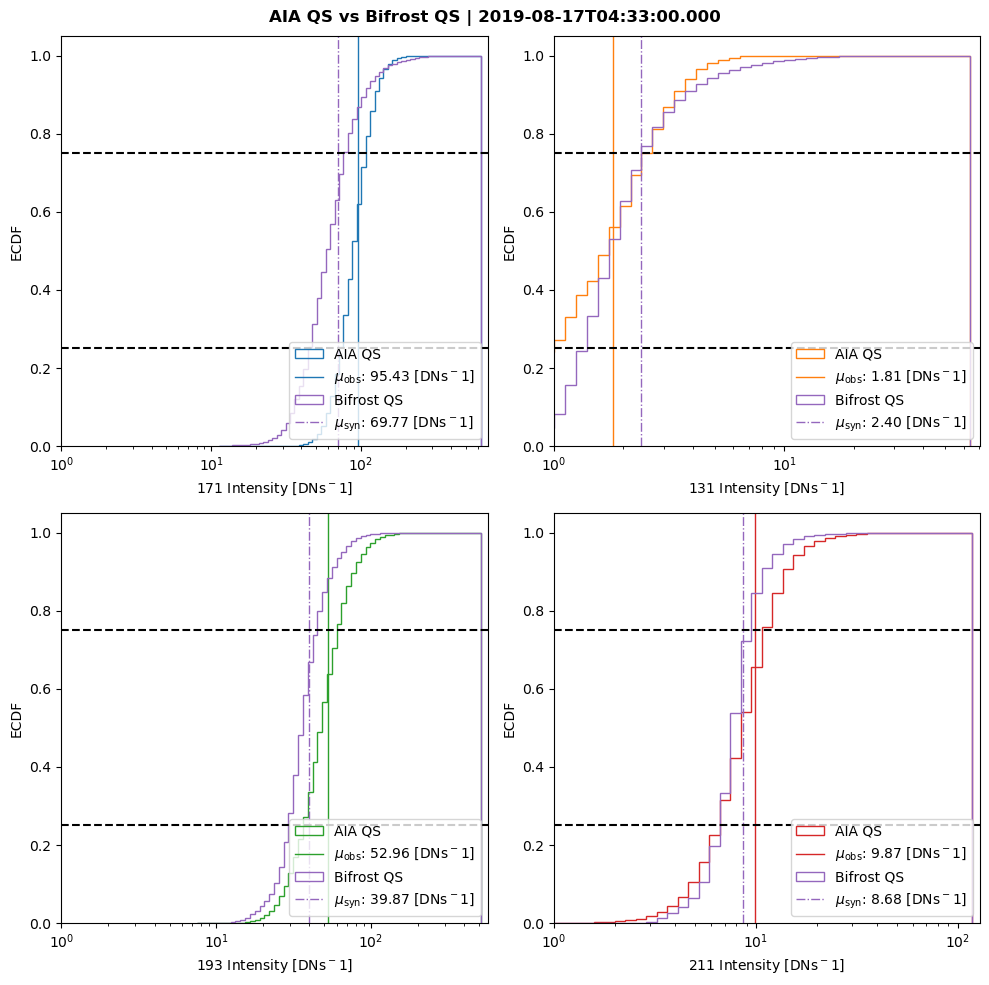

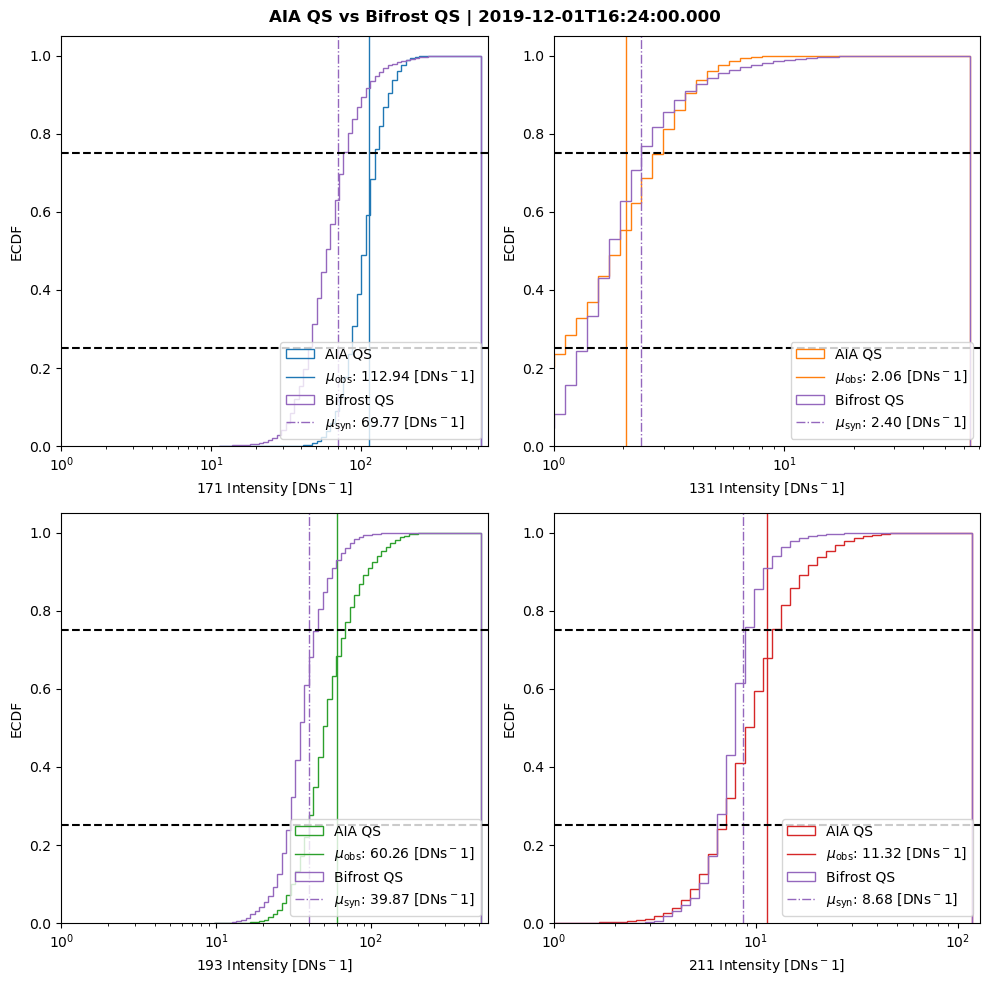

In [7]:
region = 'QS'
num_bins = 60
colors_channel = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
channels = [131,171,193,211]
MHD_code ='Bifrost'
snapname = 'QS'
os.environ['VDEM_path'] = '/Users/souvikb/MUSE_outputs/vdems/'
vdem_file = os.path.join(os.environ['VDEM_path'], 'muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr')
qs_vdem = xr.open_zarr(vdem_file)
os.environ['RESPONSE'] = '/Users/souvikb/MUSE_outputs/response/new_response/'
work_dir = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/'
# date_sensitive = True
units = 'DN'
for idx, file in enumerate(sorted(aia_data_npz)):
    s = file
    stem = Path(s).stem # gives the filename without directory path and without the final extension
    m = re.search(r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}", stem) # scans stem for a datetime pattern like YYYY-MM-DDTHH:MM:SS
    dt_str = m.group(0) if m else None

    ## Begin the Response function and AIA synthesis section 
    date = Time(dt_str,format='isot',scale='utc') # astropy time object
    print(f' Date Sensitive AIA {units} Response from {date.strftime("%b %y")}')
    aia_resp = get_response(qs_vdem, date = date, save_response = True) # creating AIA response functions on the fly
    muse_AIA_QS = aia_synthesis(aia_resp, work_dir, vdem_file, swap_dims = False) # Synthesizing AIA QS data from VDEM
    
    with np.load(file, allow_pickle=True) as z:
        all_aia_data = {k:z[k] for k in z.files}
    print(f"Processing .npz file: {file}")

    fig, ax = plt.subplots(2,2,figsize=(10,10))
    fig.suptitle(f"AIA QS vs Bifrost QS | {date}", fontsize=12,y=0.98, fontweight='bold')
    # for i, channel in enumerate(channels):
    for i, (k, v) in enumerate(all_aia_data.items()):
        obs_data = np.ravel(v.item().data) # not needed to divide by the exposure time because the saved data is already divided.
        synth_data = muse_AIA_QS.flux.sel(channel=int(k[1:])).squeeze().to_numpy()
        combined = np.concatenate([obs_data, synth_data.ravel()])
        min_val = max(combined.min(), 1e-1)  # avoiding log(0). This can be nasty otherwise
        max_val = combined.max()
        obs_plot = obs_data[np.isfinite(obs_data) & (obs_data >= min_val)]
        syn_plot = synth_data[np.isfinite(synth_data) & (synth_data >= min_val)]
        bins_new = np.logspace(np.log10(min_val), np.log10(max_val), num_bins)
        hist, bin_edges = np.histogram(obs_data, bins=bins_new)
        ax[i//2][i%2].hist(obs_plot, bins=bins_new, label=f'AIA {region}',cumulative=True, histtype='step',
                            weights=np.ones(len(obs_plot)) / len(obs_plot), color=colors_channel[i], lw=2.)
        ax[i//2][i%2].axvline(x=np.mean(obs_data),color=colors_channel[i],lw=1,ls='-',
                                label=f'$\mu_{{\mathrm{{obs}}}}$: {np.mean(obs_data):.2f} [DNs$^{-1}$]')

        ax[i//2][i%2].hist(syn_plot, bins=bins_new, label=f'{MHD_code} {snapname}',cumulative=True, histtype='step',
                            weights=np.ones(len(syn_plot)) / len(syn_plot),color='tab:purple',ls='-.',lw=2.)
        ax[i//2][i%2].axvline(x=np.mean(synth_data.ravel()),color='tab:purple',lw=1,ls='-.',label=f'$\mu_{{\mathrm{{syn}}}}$: {np.mean(synth_data.ravel()):.2f} [DNs$^{-1}$]')
        ax[i//2][i%2].set_xlabel(fr'{int(k[1:])} Intensity [DNs$^{-1}$]')
        ax[i//2][i%2].set_xlim([1, max_val * 1.1])
        ax[i//2][i%2].set_xscale('log')
        ax[i//2][i%2].set_ylabel('ECDF')
        ax[i//2][i%2].legend(loc='lower right')
        ax[i//2][i%2].axhline(y=0.25,color='black',ls='--')
        ax[i//2][i%2].axhline(y=0.75,color='black',ls='--')
    plt.tight_layout()


/var/folders/nk/5w7wz2p12dj2qhgqnyrvk0hh0000gp/T/ipykernel_3132/148796632.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([''])


Text(0.5, 0.93, 'SDO/AIA QS synthetics')

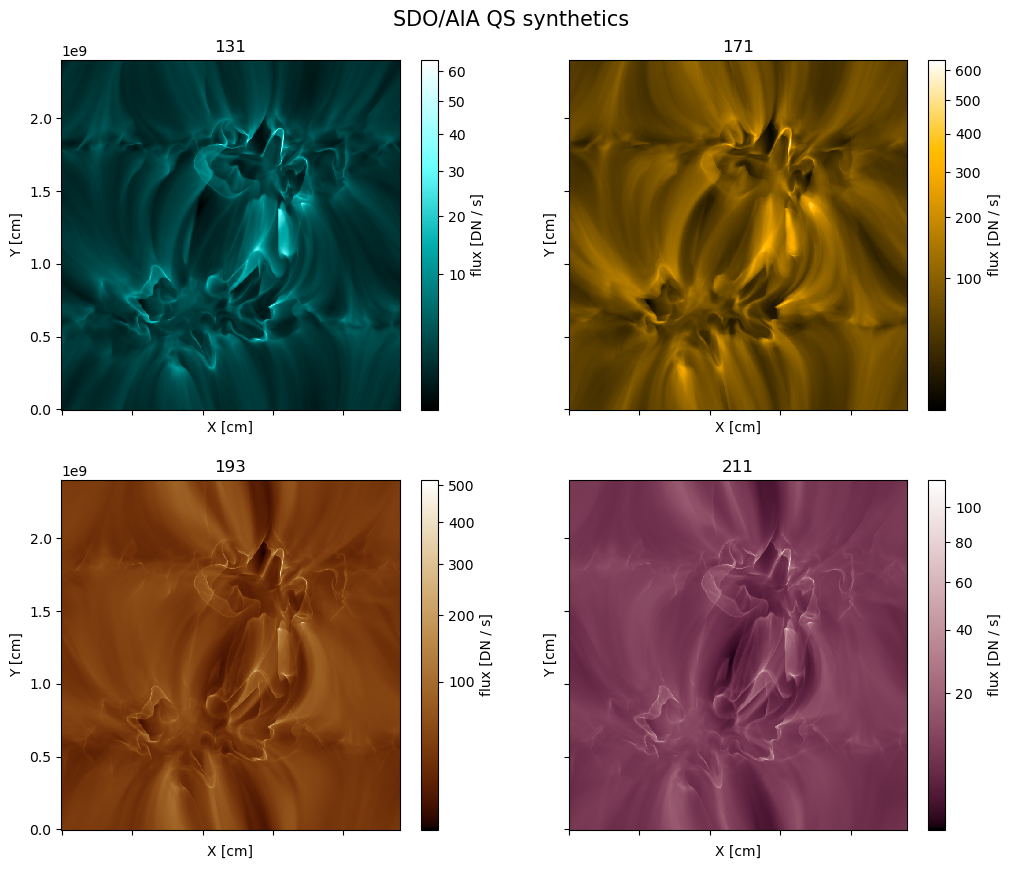

In [8]:
from matplotlib import colors
fig, axs = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(12,10))
axs = axs.ravel()

muse_AIA_QS.flux.sel(channel=131).T.plot(ax=axs[0], norm=colors.PowerNorm(0.5), cmap='sdoaia131')
axs[0].set_title('131')
axs[0].set_xticklabels([''])
muse_AIA_QS.flux.sel(channel=171).T.plot(ax=axs[1], norm=colors.PowerNorm(0.5), cmap='sdoaia171')
axs[1].set_title('171')
muse_AIA_QS.flux.sel(channel=193).T.plot(ax=axs[2], norm=colors.PowerNorm(0.5), cmap='sdoaia193')
axs[2].set_title('193')
muse_AIA_QS.flux.sel(channel=211).T.plot(ax=axs[3], norm=colors.PowerNorm(0.5), cmap='sdoaia211')
axs[3].set_title('211')
fig.suptitle('SDO/AIA QS synthetics',y=0.93,size=15)

In [6]:
## Investigating the QS datasets to make sure what is wrong with AIA 131

test_aia = np.load('/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_AIA_2019-08-17T04:33:00.npz',allow_pickle=True)
test_aia_131 = test_aia['a131']
# test_aia_131.peek()

Observatory,SDO
Instrument,AIA 1
Detector,AIA
Measurement,131.0 Angstrom
Wavelength,131.0 Angstrom
Observation Date,2019-08-17 04:34:42
Exposure Time,2.900824 s
Dimension,[437. 855.] pix
Coordinate System,helioprojective
Scale,[0.60069799 0.60069799] arcsec / pix
Reference Pixel,[ 40.56226 617.40356] pix

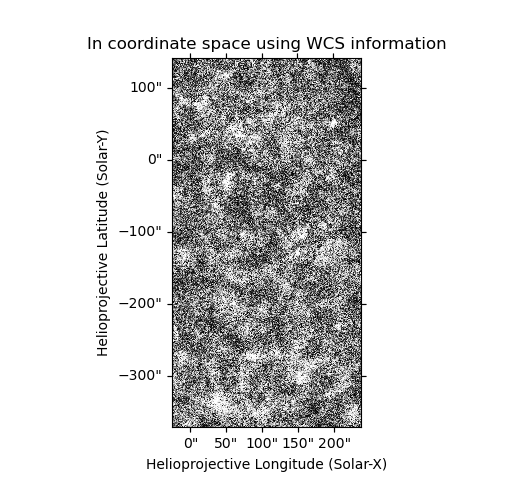
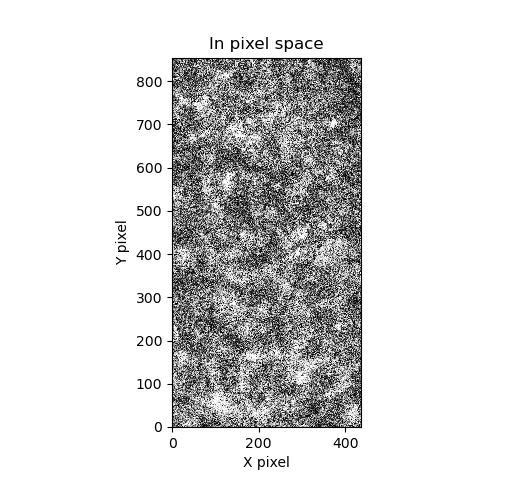
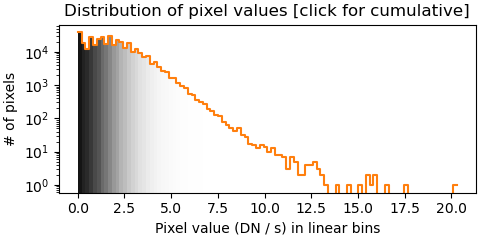
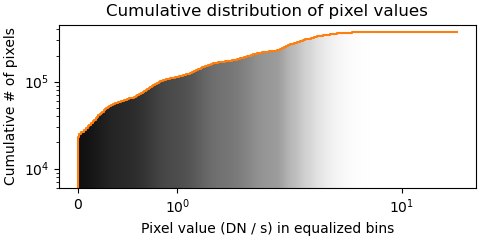

In [28]:
test_aia_131.item()

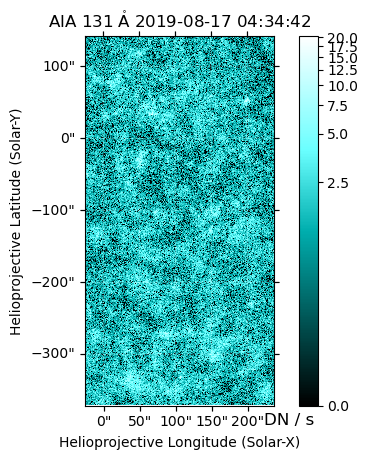

In [17]:
test_aia_131.item().peek()